# Task 1
Підготуйте та завантажте дані.
* Збережіть у CSV-файл 10-15 текстових відгуків клієнтів (англійською мовою).
* Завантажте дані за допомогою pandas.
* Обробіть тексти: приведіть до нижнього регістру, видаліть спецсимволи та цифри.
* Перевірте кількість рядків і середню довжину відгуків (у словах).

In [1]:
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt
from IPython.display import Markdown as md
from nltk import bigrams

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

reviews_data = [
    "The product is amazing, really great quality and fast shipping!",
    "Terrible experience. The shipping took 3 weeks and it arrived broken.",
    "Good value for the price, but the battery life is just okay.",
    "I absolutely love this! Highly recommend it to everyone. Great quality.",
    "Not worth the money. Very poor build quality and bad customer service.",
    "Excellent product. Works exactly as described. 10/10.",
    "It is decent, but I have seen better alternatives for cheaper.",
    "The quality is outstanding and the packaging was beautiful.",
    "Failed after two days of use. Completely useless product.",
    "Great customer support, they replaced my defective unit quickly.",
    "Average product, nothing special but it does the job.",
    "Fantastic quality and very fast delivery. Very happy with the purchase.",
    "Bad quality, terrible customer service, totally disappointed."
]

df = pd.DataFrame({'review': reviews_data})
df.to_csv('feedback.csv', index=False)

df = pd.read_csv('feedback.csv')

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['cleaned_review'] = df['review'].apply(clean_text)

num_rows = len(df)
avg_length = df['cleaned_review'].apply(lambda x: len(x.split())).mean()

task1_md = f"""
| Metric | Value |
|---|---|
| Total Rows | {num_rows} |
| Average Length (words) | {avg_length:.2f} |
"""
md(task1_md)


| Metric | Value |
|---|---|
| Total Rows | 13 |
| Average Length (words) | 9.69 |


# Task 2
Застосуйте токенізацію і видаліть стоп-слова.
* Розділіть тексти на токени за допомогою nltk.word_tokenize.
* Видаліть стоп-слова з бібліотеки nltk.corpus.stopwords.
* Видаліть усі токени довжиною менше 3 символів.
* Підрахуйте загальну кількість токенів до і після очищення.

In [2]:
stop_words = set(stopwords.words('english'))

total_tokens_before = 0
total_tokens_after = 0
all_cleaned_tokens = []

for text in df['cleaned_review']:
    tokens = word_tokenize(text)
    total_tokens_before += len(tokens)
    
    cleaned_tokens = [word for word in tokens if word not in stop_words and len(word) >= 3]
    total_tokens_after += len(cleaned_tokens)
    all_cleaned_tokens.extend(cleaned_tokens)

task2_md = f"""
| Token State | Count |
|---|---|
| Before cleaning | {total_tokens_before} |
| After cleaning | {total_tokens_after} |
"""
md(task2_md)


| Token State | Count |
|---|---|
| Before cleaning | 126 |
| After cleaning | 81 |


# Task 3
Побудуйте частотний словник і візуалізуйте результати.
* Використовуйте collections.Counter для підрахунку зустрічальності слів.
* Виведіть 15 найчастіших слів та їхню кількість.
* Побудуйте горизонтальну діаграму за допомогою matplotlib
* Підпишіть осі та заголовок графіка (Top 15 Frequent Words).
* Збережіть зображення як feedback_word_freq.png.

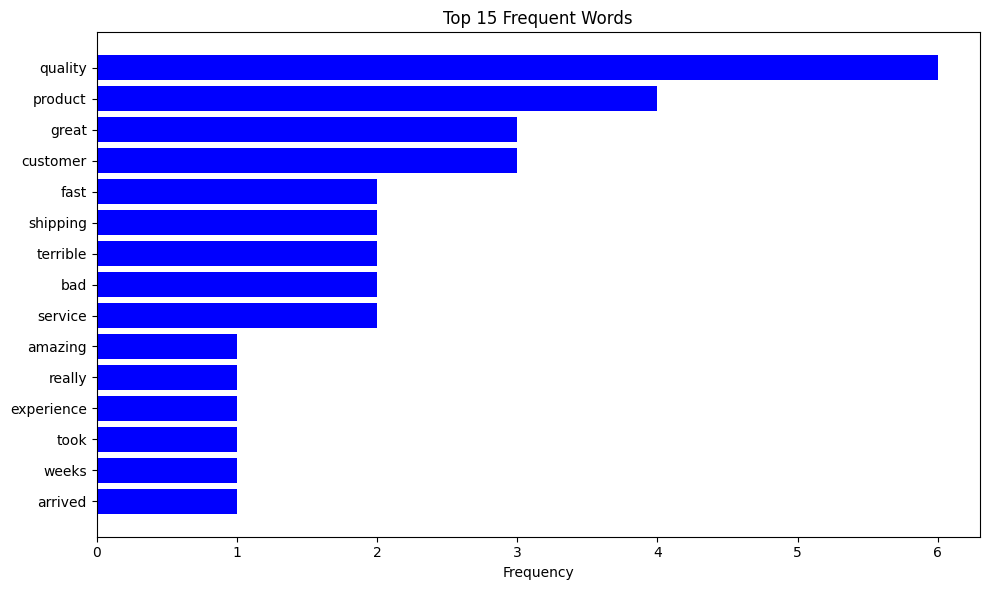

In [3]:
word_counts = Counter(all_cleaned_tokens)
top_15_words = word_counts.most_common(15)

task3_md = "| Word | Frequency |\n|---|---|\n"
for word, count in top_15_words:
    task3_md += f"| {word} | {count} |\n"
md(task3_md)

words, counts = zip(*top_15_words)

plt.figure(figsize=(10, 6))
plt.barh(words[::-1], counts[::-1], color='blue')
plt.xlabel('Frequency')
plt.title('Top 15 Frequent Words')
plt.tight_layout()
plt.savefig('feedback_word_freq.png')
plt.show()

# Task 4
Додатковий аналіз біграм.
* Згенеруйте біграми (послідовності з двох слів) за допомогою nltk.bigrams.
* Підрахуйте частоту появи біграм.
* Відобразіть 10 найчастіших біграм у вигляді таблиці
* Збережіть результати в CSV-файл feedback_bigrams.csv.

In [7]:
bigram_list = list(bigrams(all_cleaned_tokens))
bigram_counts = Counter(bigram_list)
top_10_bigrams = bigram_counts.most_common(10)

task4_md = "| Bigram | Frequency |\n|---|---|\n"
for bg, count in top_10_bigrams:
    bg_str = f"{bg[0]} {bg[1]}"
    task4_md += f"| {bg_str} | {count} |\n"
display(md(task4_md))

bigram_df = pd.DataFrame([(" ".join(bg), count) for bg, count in top_10_bigrams], columns=['Bigram', 'Frequency'])
bigram_df.to_csv('feedback_bigrams.csv', index=False)

| Bigram | Frequency |
|---|---|
| great quality | 2 |
| quality fast | 2 |
| customer service | 2 |
| product amazing | 1 |
| amazing really | 1 |
| really great | 1 |
| fast shipping | 1 |
| shipping terrible | 1 |
| terrible experience | 1 |
| experience shipping | 1 |
